In [1]:
!pip3 install pandas
import pandas as pd
import numpy as np

df = pd.read_csv("/workspaces/ml-assessment-swethapriya/data/q2_customers.csv")
print(df)

     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0     30         43075                 9         2080                     45   
1     19         14496                11          454                      8   
2     43         57632                 6         2144                     16   
3     30         15629                10          801                      0   
4     19         14901                16          396                     17   
..   ...           ...               ...          ...                    ...   
495   20         22094                13          729                      3   
496   53         63845                 1         7371                     30   
497   44         53558                 9          906                     10   
498   36         41202                 9         2046                     47   
499   20          8118                15          865                     16   

     num_categories_purchased  
0      

In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# droping any non-numberic columns
df_numeric = df.select_dtypes(include = 'number')

#Scaling the feature using standard scaler
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_numeric)

print(df_numeric.describe().round(2))
print(scaled_df.shape)
#print(scaled_df.round(2))

          age  annual_spend  visits_per_month  basket_size  \
count  500.00        500.00            500.00       500.00   
mean    40.45      48856.95              8.41      2682.29   
std     14.43      32856.80              5.32      2274.96   
min     18.00       5038.00              1.00       212.00   
25%     28.00      19213.25              4.00       727.75   
50%     41.00      44257.00              8.00      2051.50   
75%     50.00      75373.00             12.00      4223.75   
max     69.00     119757.00             19.00      7981.00   

       days_since_last_visit  num_categories_purchased  
count                 500.00                    500.00  
mean                   49.47                      4.66  
std                    49.70                      2.44  
min                     0.00                      1.00  
25%                    12.00                      3.00  
50%                    33.00                      4.00  
75%                    61.25              

Standard scaler fixes the data by transforming every feature to have a mean of  0 and Standard deviation of 1, so that feature contributes equally when K-means measures distances. without scaling the results will be misleading and will be biased to high ranked(marked) features.

For example: if we consider age between 18-70 and annual income between 20k-200K, income will dominate just because numbers are high which clearly shows biased data.



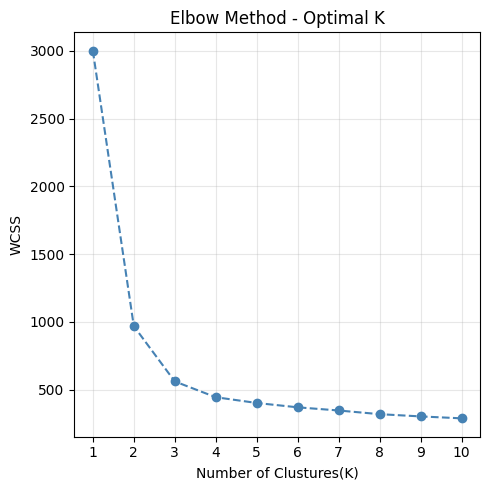

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(5,5))
plt.plot(range(1,11), wcss, marker = 'o', linestyle='--', color = 'steelblue')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clustures(K)')
plt.ylabel('WCSS')
plt.xticks(range(1,11))
plt.grid(True, alpha= 0.3)
plt.tight_layout()
plt.show()

The elbow plot shows WCSS dropping steeply from k=1 to k=3,  after which the rate of decrease slows down significantly and the curve begins to flatten. This elbow point at k = 3 suggests that adding more clustures beyond 3 gives very little improvement. 
So, k = 3 is selected as optimal number of clustures.It captures the main natural groupings in the data without overfitting by creating many small fragmented clustures.
